In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from collections import Counter
import matplotlib.pyplot as plt
import json
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


In [7]:
df = pd.read_parquet("../data/processed/hdfs_sequences.parquet")

with open("../data/processed/template_map.json", 'r') as f:
    template_map = json.load(f)

num_events = max(e for seq in df['sequence'] for e in seq) + 1

normal_df = df[df['label'] == 'Normal']
anomaly_df = df[df['label'] == 'Anomaly']

print(f"Total blocks: {len(df):,}")
print(f"Normal: {len(normal_df):,}")
print(f"Anomaly: {len(anomaly_df):,}")
print(f"Event vocabulary size: {num_events}")

Total blocks: 575,061
Normal: 558,223
Anomaly: 16,838
Event vocabulary size: 46


In [8]:
WINDOW_SIZE = 10

def create_windows(sequences, window_size):
    """Create sliding windows from a list of sequences."""
    X, y = [], []
    for seq in sequences:
        if len(seq) <= window_size:
            continue
        for i in range(len(seq) - window_size):
            X.append(seq[i:i + window_size])
            y.append(seq[i + window_size])
    return np.array(X), np.array(y)

train_seqs, test_normal_seqs = train_test_split(
    normal_df['sequence'].tolist(),
    test_size=0.2,
    random_state=42,
)

X_train, y_train = create_windows(train_seqs, WINDOW_SIZE)

print(f"Training windows: {len(X_train):,}")
print(f"Example input:  {X_train[0]}")
print(f"Example target: {y_train[0]}")

Training windows: 4,246,044
Example input:  [1 1 1 2 3 4 3 4 3 4]
Example target: 5


In [9]:
class LogDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 1024

train_dataset = LogDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"Dataset size: {len(train_dataset):,}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Batches per epoch: {len(train_loader):,}")

sample_x, sample_y = next(iter(train_loader))
print(f"\nSample batch X shape: {sample_x.shape}")
print(f"Sample batch y shape: {sample_y.shape}")

Dataset size: 4,246,044
Batch size: 1024
Batches per epoch: 4,147

Sample batch X shape: torch.Size([1024, 10])
Sample batch y shape: torch.Size([1024])


In [10]:
class DeepLog(nn.Module):
    def __init__(self, num_events, hidden_size=64, num_layers=2):
        super(DeepLog, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.embedding = nn.Embedding(num_events, hidden_size)
        self.lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, num_events)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        last_output = lstm_out[:, -1, :]
        output = self.fc(last_output)
        return output

model = DeepLog(num_events=num_events, hidden_size=64, num_layers=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Device: {device}")

Model architecture:
DeepLog(
  (embedding): Embedding(46, 64)
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=46, bias=True)
)

Total parameters: 72,494
Device: cuda


In [11]:
NUM_EPOCHS = 10
LEARNING_RATE = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Training DeepLog for {NUM_EPOCHS} epochs...")
print(f"Learning rate: {LEARNING_RATE}")
print("-" * 50)

train_losses = []

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        output = model(batch_x)
        loss = criterion(output, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = torch.max(output, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = correct / total
    train_losses.append(avg_loss)
    
    print(f"Epoch {epoch+1:>2}/{NUM_EPOCHS} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.4f}")

print("-" * 50)
print("Training complete!")

Training DeepLog for 10 epochs...
Learning rate: 0.001
--------------------------------------------------
Epoch  1/10 | Loss: 0.2521 | Accuracy: 0.9082
Epoch  2/10 | Loss: 0.1921 | Accuracy: 0.9222
Epoch  3/10 | Loss: 0.1896 | Accuracy: 0.9228
Epoch  4/10 | Loss: 0.1885 | Accuracy: 0.9232
Epoch  5/10 | Loss: 0.1878 | Accuracy: 0.9233
Epoch  6/10 | Loss: 0.1873 | Accuracy: 0.9234
Epoch  7/10 | Loss: 0.1870 | Accuracy: 0.9236
Epoch  8/10 | Loss: 0.1867 | Accuracy: 0.9237
Epoch  9/10 | Loss: 0.1865 | Accuracy: 0.9237
Epoch 10/10 | Loss: 0.1863 | Accuracy: 0.9237
--------------------------------------------------
Training complete!


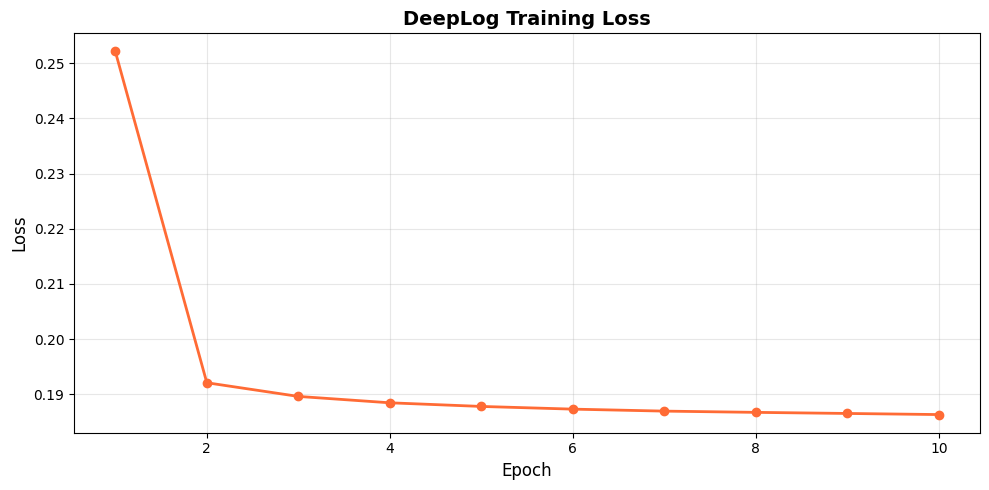

Saved: docs/images/04_training_loss.png


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', color='#ff6b35', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('DeepLog Training Loss', fontweight='bold', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/images/04_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: docs/images/04_training_loss.png")

In [ ]:
print(model)